In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.concat([
    pd.read_csv('../results/r4_baseline.csv'), 
    pd.read_csv('../results/r4i1_ml_cf_rfc.csv'), 
])
df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['reval_pending'] = df.revals - df.hit_reval - df.reval_wasted
df['fresh_pc'] = df.hit_fresh / df['all'] * 100
df['reval_pc'] = df.hit_reval / df['all'] * 100
df['miss_pc'] = df['miss_all'] / df['all'] * 100
df['miss_non1st_pc'] = (df['miss_all'] - df['miss_mandatory']) / df['all'] * 100
df['amp_lower'] = df['reval_wasted'] / (df['miss_all'] + df['hit_reval']) + 1
df['amp_upper'] = (df['reval_wasted'] + df['reval_pending']) / (df['miss_all'] + df['hit_reval']) + 1
df['amp_avg'] = (df['amp_lower'] + df['amp_upper']) / 2
df['reval_precision'] = (df['hit_reval'] / (df['hit_reval'] + df['reval_wasted'])).fillna(1)
df = df[df['mlthres'] > 0.5]
df.head()

,in,gib,ksr,mode,model,mlthres,rv_min_ttl,rv_min_freq,rv_max_za,all,...,miss_all,reval_pending,fresh_pc,reval_pc,miss_pc,miss_non1st_pc,amp_lower,amp_upper,amp_avg,reval_precision
0,cf_d,2048,1,oracle,NaN,1.0,0,0,0,633171872,...,106541076,0,81.703175,1.470260,16.826565,4.996395,1.001454,1.001454,1.001454,0.982225
1,cf_c,2048,1,oracle,NaN,1.0,0,0,0,585034315,...,97978863,0,81.806964,1.445495,16.747541,4.925196,1.001037,1.001037,1.001037,0.987117
2,cf_c,2048,1,oracle,NaN,1.0,0,0,0,585034315,...,97978863,0,81.806964,1.445495,16.747541,4.925196,1.001037,1.001037,1.001037,0.987117
3,cf_d,2048,1,never,NaN,1.0,0,0,0,633171872,...,114466747,0,81.921694,0.000000,18.078306,6.248136,1.000000,1.000000,1.000000,1.000000
4,cf_a,2048,1,oracle,NaN,1.0,0,0,0,611934080,...,59914262,0,89.077530,1.131503,9.790967,3.353349,1.001089,1.001089,1.001089,0.989595


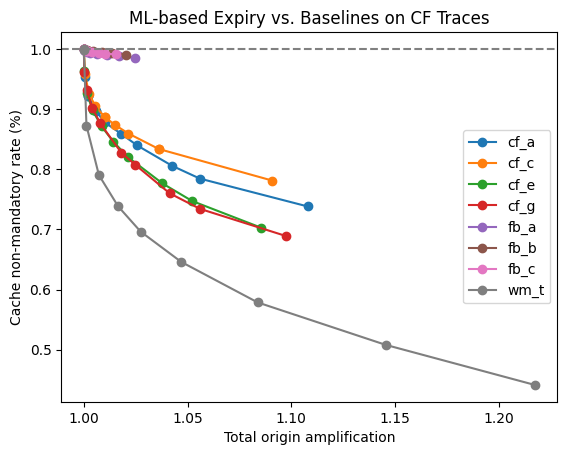

In [3]:
# normalised graph
for s in ['cf_a', 'cf_c', 'cf_e', 'cf_g', 'fb_a', 'fb_b', 'fb_c', 'wm_t']:
    df_s = df[(df['in'] == s) & (df['mode'] == 'ml') & (df['amp_avg'] < 2)].sort_values('mlthres')
    never_y = df[(df['in'] == s) & (df['mode'] == 'never')]['miss_non1st_pc']
    never_frac = never_y.values[0]
    plt.plot(df_s['amp_avg'], df_s['miss_non1st_pc'] / never_frac, marker='o', label=s)

plt.axhline(y=1, color='gray', linestyle='--')
plt.xlabel('Total origin amplification')
plt.ylabel('Cache non-mandatory rate (%)')
plt.title('ML-based Expiry vs. Baselines on CF Traces')
plt.legend()
plt.show()


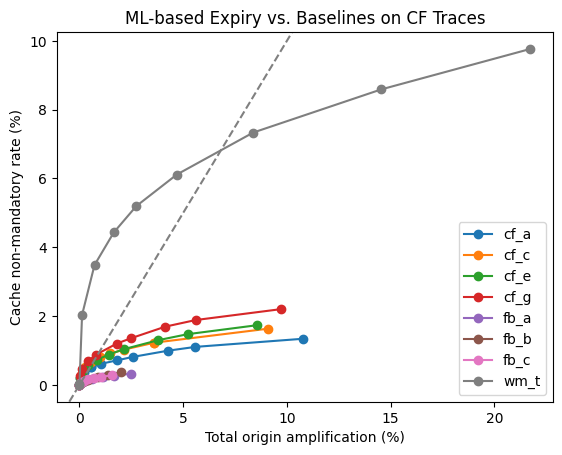

In [4]:
# normalised graph
for s in ['cf_a', 'cf_c', 'cf_e', 'cf_g', 'fb_a', 'fb_b', 'fb_c', 'wm_t']:
    df_s = df[(df['in'] == s) & (df['mode'] == 'ml') & (df['amp_avg'] < 2.01)].sort_values('mlthres')
    plt.plot((df_s['amp_avg'] - 1) * 100, df_s['reval_pc'], marker='o', label=s)

plt.axline((0,0), slope=1, color='gray', linestyle='--')
plt.xlabel('Total origin amplification (%)')
plt.ylabel('Cache non-mandatory rate (%)')
plt.title('ML-based Expiry vs. Baselines on CF Traces')
plt.legend()
plt.show()


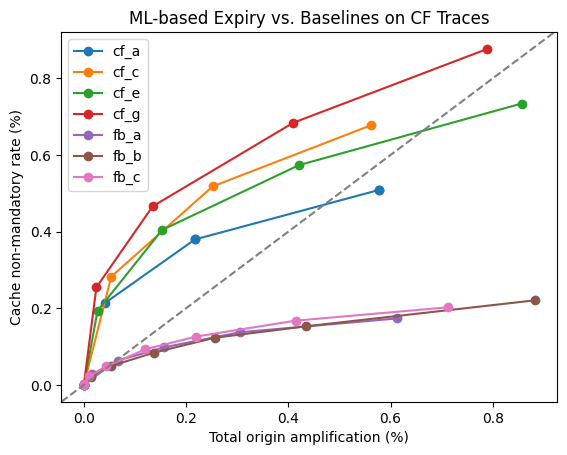

In [5]:
for s in ['cf_a', 'cf_c', 'cf_e', 'cf_g', 'fb_a', 'fb_b', 'fb_c']:
    df_s = df[(df['in'] == s) & (df['mode'] == 'ml') & (df['amp_avg'] < 1.01)].sort_values('mlthres')
    plt.plot((df_s['amp_avg'] - 1) * 100, df_s['reval_pc'], marker='o', label=s)

plt.axline((0,0), slope=1, color='gray', linestyle='--')
plt.xlabel('Total origin amplification (%)')
plt.ylabel('Cache non-mandatory rate (%)')
plt.title('ML-based Expiry vs. Baselines on CF Traces')
plt.legend()
plt.show()


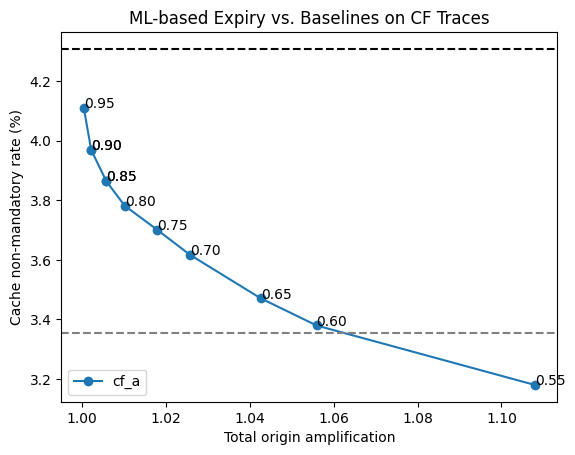

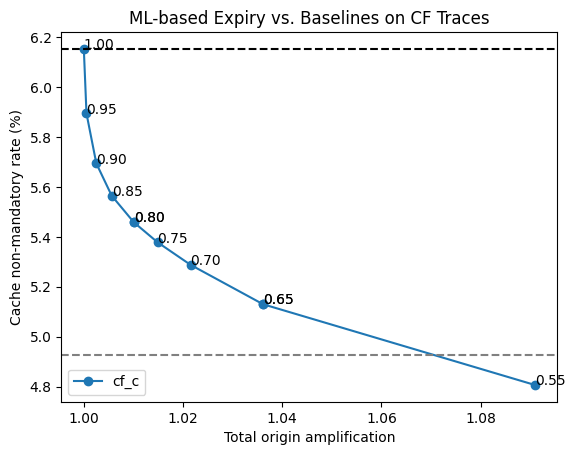

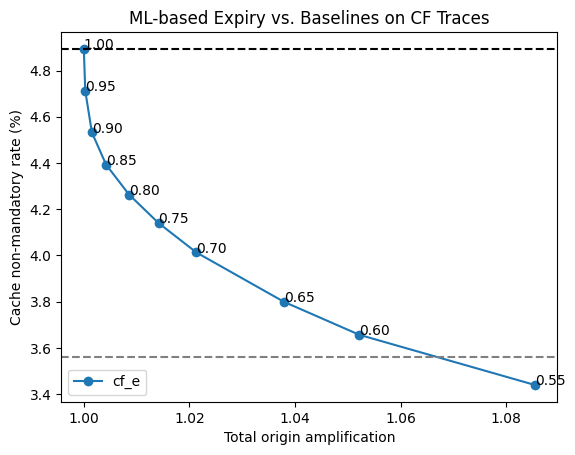

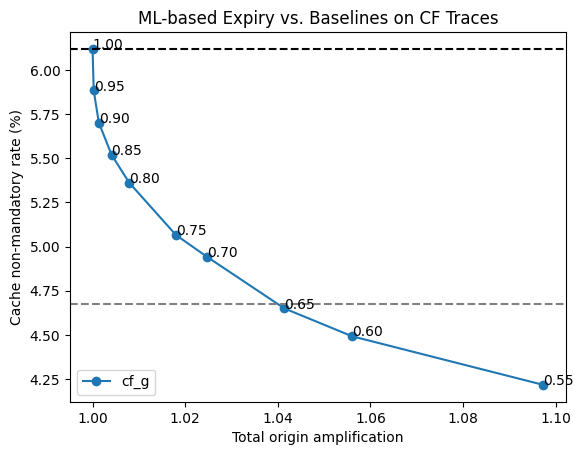

In [6]:
for s in ['cf_a', 'cf_c', 'cf_e', 'cf_g']:
    df_s = df[(df['in'] == s) & (df['mode'] == 'ml') & (df['amp_avg'] < 2)].sort_values('mlthres')
    plt.plot(df_s['amp_avg'], df_s['miss_non1st_pc'], marker='o', label=s)
    # annotate each point with mlthres
    for _, row in df_s.iterrows():
        plt.annotate(f"{row['mlthres']:.2f}", (row['amp_avg'], row['miss_non1st_pc']))
    oracle_y = df[(df['in'] == s) & (df['mode'] == 'oracle')]['miss_non1st_pc']
    plt.axhline(y=oracle_y.values[0], color='gray', linestyle='--')
    never_y = df[(df['in'] == s) & (df['mode'] == 'never')]['miss_non1st_pc']
    plt.axhline(y=never_y.values[0], color='black', linestyle='--')
    plt.xlabel('Total origin amplification')
    plt.ylabel('Cache non-mandatory rate (%)')
    plt.title('ML-based Expiry vs. Baselines on CF Traces')
    plt.legend()
    plt.show()


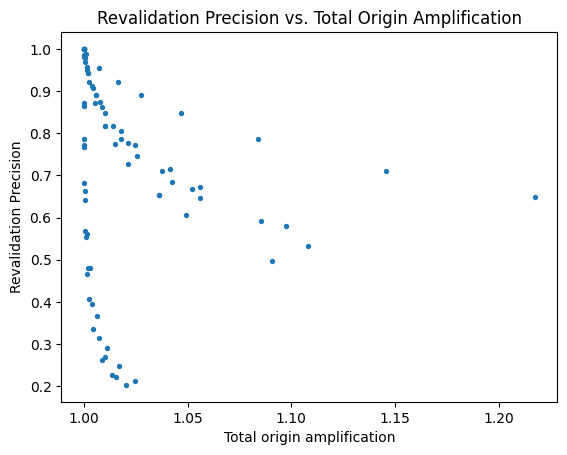

In [7]:
df_ml = df[df['mode'] == 'ml']

# compare reval precision vs origin amp
plt.scatter(df_ml['amp_avg'], df_ml['reval_precision'], marker='o', s=8)
plt.xlabel('Total origin amplification')
plt.ylabel('Revalidation Precision')
plt.title('Revalidation Precision vs. Total Origin Amplification')
plt.show()

In [8]:
never_y

17    6.119595
Name: miss_non1st_pc, dtype: float64